In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled. Using:", gpus)
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected. Go to Runtime > Change runtime type > GPU in Colab.")

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

matplotlib.rcParams['font.weight'] = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titleweight'] = 'bold'
matplotlib.rcParams['figure.dpi'] = 100

def save_bold_plot(fig, filename, plots_dir=PLOTS_DIR):
    for ax in fig.get_axes():
        if ax.get_title():
            ax.set_title(ax.get_title(), fontweight='bold', fontsize=13)
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), fontweight='bold', fontsize=11)
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), fontweight='bold', fontsize=11)
        leg = ax.get_legend()
        if leg is not None:
            for text in leg.get_texts():
                text.set_fontweight('bold')
    filepath = os.path.join(plots_dir, filename)
    fig.savefig(filepath, format='png', dpi=150, bbox_inches='tight')
    print(f"Saved: {filepath}")
    plt.show()

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)
class_names = ['Airplane','Automobile','Bird','Cat','Deer','Dog','Frog','Horse','Ship','Truck']

Num GPUs Available: 1
GPU memory growth enabled. Using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Training set shape   : (45000, 32, 32, 3) (45000, 10)
Validation set shape : (5000, 32, 32, 3) (5000, 10)
Testing set shape    : (10000, 32, 32, 3) (10000, 10)


/tmp/ipykernel_17508/3378496229.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(class_names[int(y_train_labels[i])], fontweight='bold')


Saved: plots/sample_cifar10_images.png


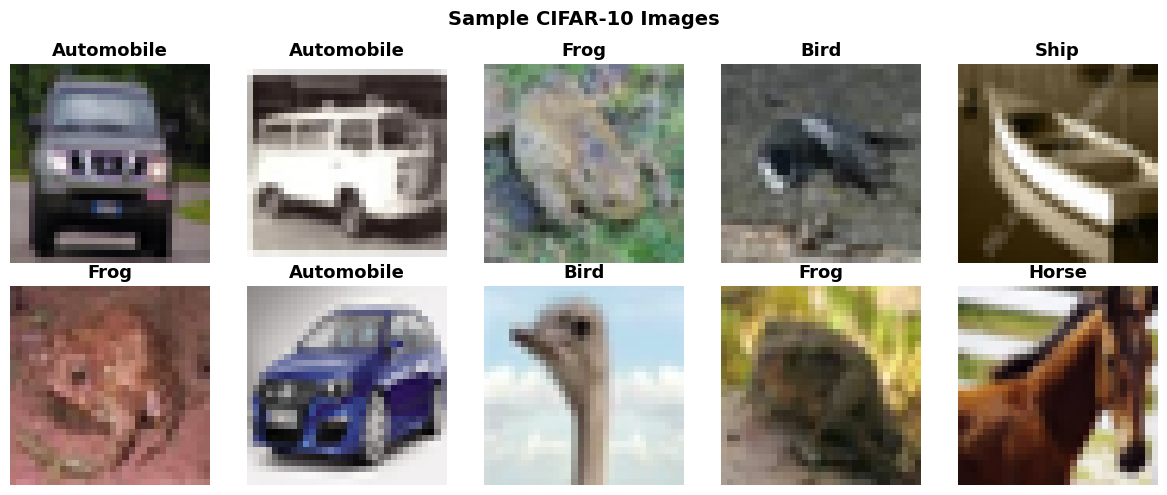

In [2]:
# Task 1: Dataset Preparation
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train, x_val, y_train_labels, y_val_labels = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

y_train = to_categorical(y_train_labels, NUM_CLASSES)
y_val = to_categorical(y_val_labels, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)
y_true = y_test.flatten()

print("Training set shape   :", x_train.shape, y_train.shape)
print("Validation set shape :", x_val.shape, y_val.shape)
print("Testing set shape    :", x_test.shape, y_test_cat.shape)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample CIFAR-10 Images", fontweight='bold', fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(y_train_labels[i])], fontweight='bold')
    ax.axis('off')
plt.tight_layout()
save_bold_plot(fig, "sample_cifar10_images.png")

In [3]:
# Task 2: Transfer Learning — Model Construction (VGG16)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam, SGD

def build_transfer_model(base_model_fn, dense_units=128, learning_rate=0.001, optimizer_name='adam'):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer: " + optimizer_name)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model

vgg_model, vgg_base = build_transfer_model(VGG16, dense_units=128, learning_rate=0.001, optimizer_name='adam')
vgg_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.5198 - loss: 1.3846 - val_accuracy: 0.5710 - val_loss: 1.2418
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5819 - loss: 1.1990 - val_accuracy: 0.6000 - val_loss: 1.1615
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5997 - loss: 1.1430 - val_accuracy: 0.6010 - val_loss: 1.1439
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6135 - loss: 1.1044 - val_accuracy: 0.6042 - val_loss: 1.1356
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6263 - loss: 1.0711 - val_accuracy: 0.6064 - val_loss: 1.1319
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6366 - loss: 1.0408 - val_accuracy: 0.6102 - val_loss: 1.1095
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6445 - loss: 1.0146 - val_accuracy: 0.6028 - val_loss: 1.1280
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6518 - loss:

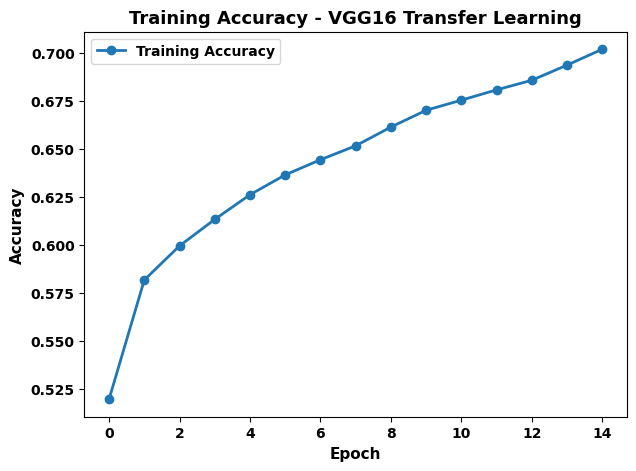

Saved: plots/validation_accuracy.png


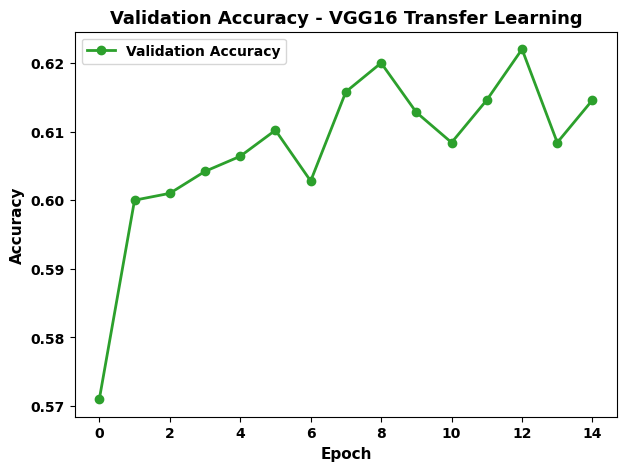

Saved: plots/training_loss.png


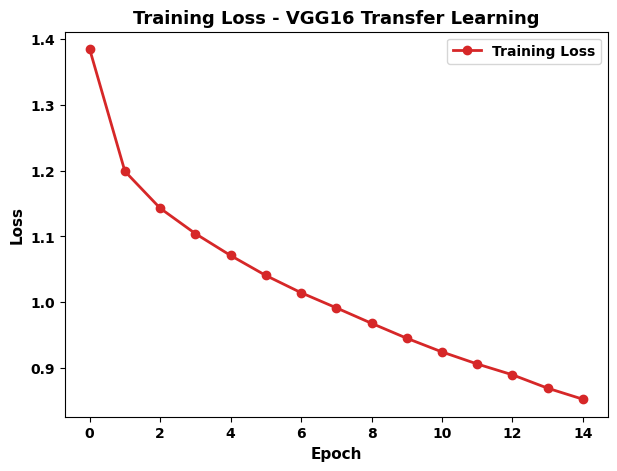

Saved: plots/validation_loss.png


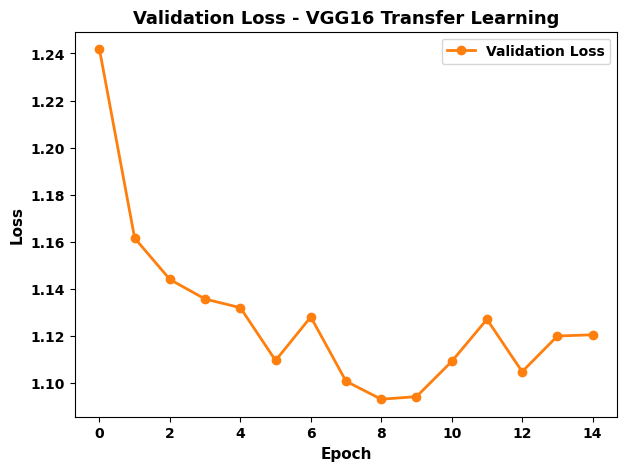

In [4]:
# Task 3: Model Training (Adam, lr=0.001, batch=32)
BATCH_SIZE = 32
EPOCHS_MAIN = 15

start_time = time.time()
history_vgg = vgg_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_MAIN,
    verbose=1
)
vgg_train_time = time.time() - start_time
print(f"VGG16 (frozen base) training time: {vgg_train_time:.2f} seconds")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_vgg.history['accuracy'], marker='o', color='#1f77b4', linewidth=2, label='Training Accuracy')
ax.set_title("Training Accuracy - VGG16 Transfer Learning")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
save_bold_plot(fig, "training_accuracy.png")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_vgg.history['val_accuracy'], marker='o', color='#2ca02c', linewidth=2, label='Validation Accuracy')
ax.set_title("Validation Accuracy - VGG16 Transfer Learning")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
save_bold_plot(fig, "validation_accuracy.png")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_vgg.history['loss'], marker='o', color='#d62728', linewidth=2, label='Training Loss')
ax.set_title("Training Loss - VGG16 Transfer Learning")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
save_bold_plot(fig, "training_loss.png")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history_vgg.history['val_loss'], marker='o', color='#ff7f0e', linewidth=2, label='Validation Loss')
ax.set_title("Validation Loss - VGG16 Transfer Learning")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
save_bold_plot(fig, "validation_loss.png")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 7,146,378 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7217 - loss: 0.7950 - val_accuracy: 0.6556 - val_loss: 1.0093
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.7720 - loss: 0.6437 - val_accuracy: 0.6802 - val_loss: 0.9724
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8131 - loss: 0.5403 - val_accuracy: 0.6952 - val_loss: 0.9506
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8442 - loss: 0.4550 - val_accuracy: 0.7022 - val_loss: 0.9362
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8697 - loss: 0.3862 - val_accuracy: 0.7054 - val_loss: 0.9577
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8937 - loss: 0.3248 - val_accuracy: 0.7066 - val_loss: 0.9677
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9133 - loss: 0.2730 - val_accuracy: 0.7140 - val_loss: 0.9748
Epoch 8/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9326 - loss: 0

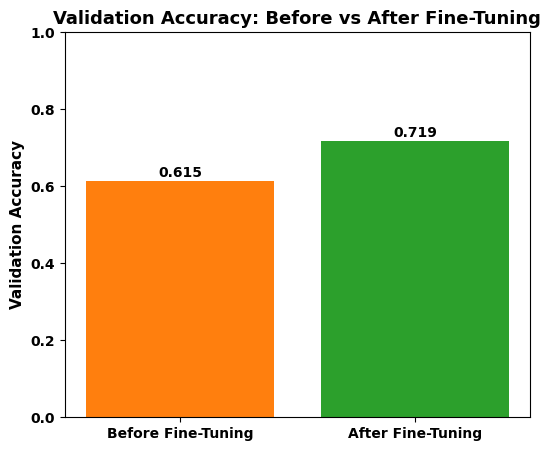

In [5]:
# Task 4: Fine Tuning
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = layer.name.startswith('block5')

vgg_model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

EPOCHS_FINETUNE = 8

start_time = time.time()
history_finetune = vgg_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_FINETUNE,
    verbose=1
)
vgg_finetune_time = time.time() - start_time

acc_before_ft = history_vgg.history['val_accuracy'][-1]
acc_after_ft = history_finetune.history['val_accuracy'][-1]

print(f"Fine-tuning time: {vgg_finetune_time:.2f} seconds")
print(f"Validation accuracy before fine-tuning: {acc_before_ft:.4f}")
print(f"Validation accuracy after fine-tuning : {acc_after_ft:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Before Fine-Tuning', 'After Fine-Tuning'], [acc_before_ft, acc_after_ft],
              color=['#ff7f0e', '#2ca02c'])
ax.set_title("Validation Accuracy: Before vs After Fine-Tuning")
ax.set_ylabel("Validation Accuracy")
ax.set_ylim(0, 1)
for i, v in enumerate([acc_before_ft, acc_after_ft]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
save_bold_plot(fig, "before_after_finetuning_accuracy.png")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step
Test Accuracy        : 0.7048
Precision (macro avg): 0.7028
Recall (macro avg)   : 0.7048
F1-score (macro avg) : 0.7027

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.79      0.76      0.77      1000
  Automobile       0.77      0.83      0.79      1000
        Bird       0.71      0.59      0.64      1000
         Cat       0.53      0.50      0.51      1000
        Deer       0.65      0.65      0.65      1000
         Dog       0.62      0.57      0.59      1000
        Frog       0.71      0.76      0.73      1000
       Horse       0.72      0.79      0.75      1000
        Ship       0.81      0.82      0.82      1000
       Truck       0.74      0.78      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000

Saved: plots/confusion_matrix.png


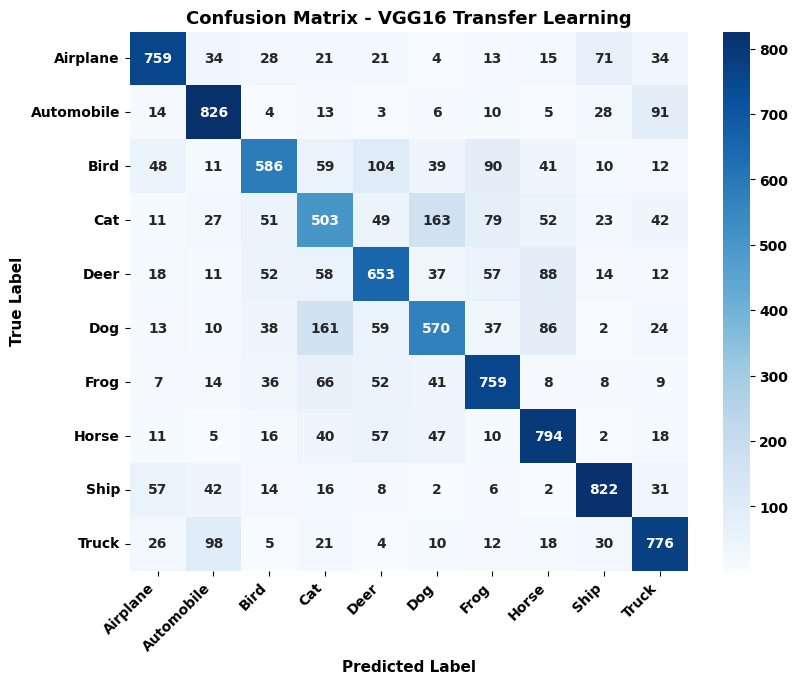

Saved: plots/misclassified_images.png


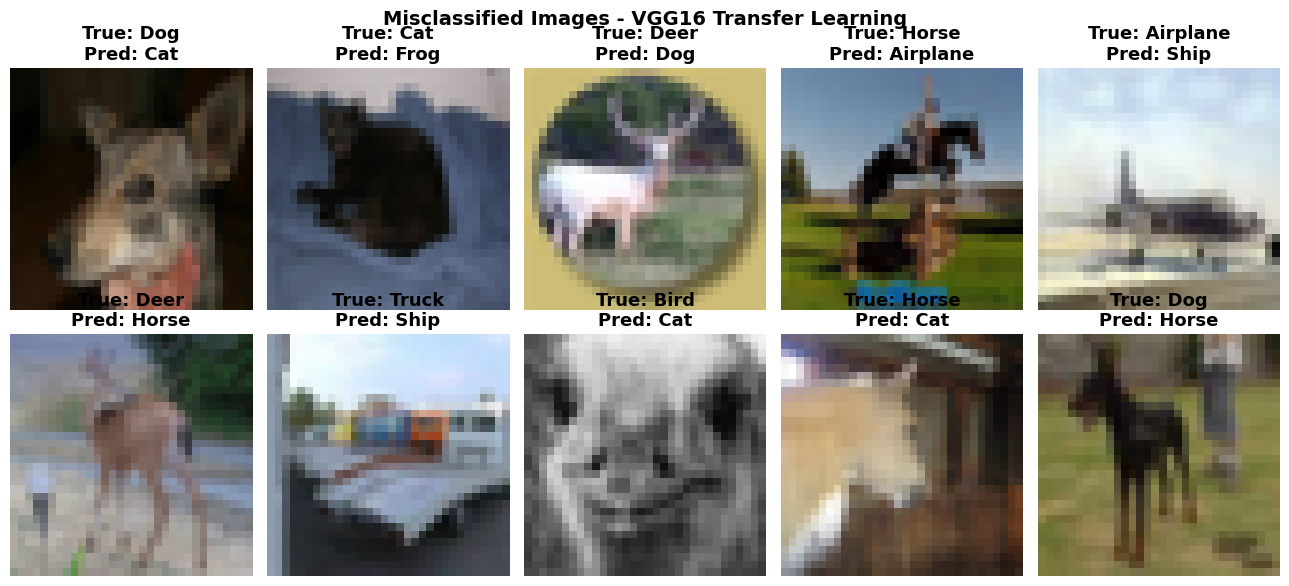

In [6]:
# Task 5: Model Evaluation
y_pred_probs = vgg_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='macro')
test_recall = recall_score(y_true, y_pred, average='macro')
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy        : {test_accuracy:.4f}")
print(f"Precision (macro avg): {test_precision:.4f}")
print(f"Recall (macro avg)   : {test_recall:.4f}")
print(f"F1-score (macro avg) : {test_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - VGG16 Transfer Learning")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontweight='bold')
plt.setp(ax.get_yticklabels(), rotation=0, fontweight='bold')
save_bold_plot(fig, "confusion_matrix.png")

misclassified_idx = np.where(y_pred != y_true)[0]
n_show = min(10, len(misclassified_idx))
sample_misclassified = np.random.choice(misclassified_idx, size=n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle("Misclassified Images - VGG16 Transfer Learning", fontweight='bold', fontsize=14)
for i, idx in enumerate(sample_misclassified):
    ax = axes.flat[i]
    ax.imshow(x_test[idx])
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
                 fontweight='bold', fontsize=9)
    ax.axis('off')
for j in range(n_show, len(axes.flat)):
    axes.flat[j].axis('off')
plt.tight_layout()
save_bold_plot(fig, "misclassified_images.png")

In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam, SGD

def build_transfer_model(base_model_fn, dense_units=128, learning_rate=0.001, optimizer_name='adam'):
    base_model = base_model_fn(weights='imagenet', include_top=False, input_shape=INPUT_SHAPE)
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(dense_units, activation='relu')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    if optimizer_name == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError("Unsupported optimizer: " + optimizer_name)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model


Training config: {'learning_rate': 0.001, 'batch_size': 32, 'optimizer_name': 'adam', 'dense_units': 128}
  -> val_accuracy: 0.6058, time: 71.2s

Training config: {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer_name': 'adam', 'dense_units': 128}
  -> val_accuracy: 0.5764, time: 69.3s

Training config: {'learning_rate': 0.001, 'batch_size': 64, 'optimizer_name': 'adam', 'dense_units': 128}
  -> val_accuracy: 0.6062, time: 56.8s

Training config: {'learning_rate': 0.001, 'batch_size': 32, 'optimizer_name': 'sgd', 'dense_units': 128}
  -> val_accuracy: 0.5506, time: 70.1s

Training config: {'learning_rate': 0.001, 'batch_size': 32, 'optimizer_name': 'adam', 'dense_units': 256}
  -> val_accuracy: 0.6066, time: 69.7s
Saved: plots/hyperparameter_comparison.png


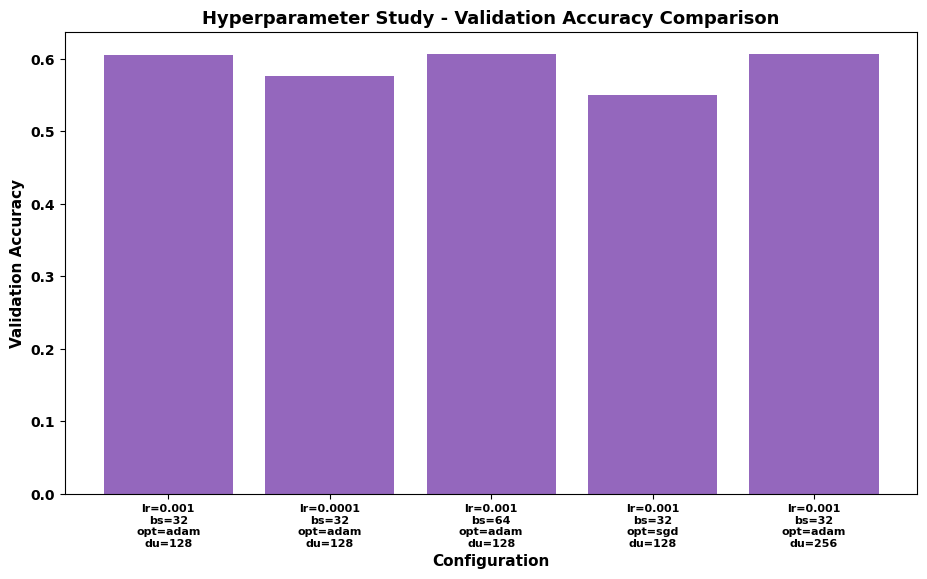

In [8]:
# Hyperparameter Study
EPOCHS_HP = 5

hyperparam_configs = [
    {'learning_rate': 0.001,  'batch_size': 32, 'optimizer_name': 'adam', 'dense_units': 128},
    {'learning_rate': 0.0001, 'batch_size': 32, 'optimizer_name': 'adam', 'dense_units': 128},
    {'learning_rate': 0.001,  'batch_size': 64, 'optimizer_name': 'adam', 'dense_units': 128},
    {'learning_rate': 0.001,  'batch_size': 32, 'optimizer_name': 'sgd',  'dense_units': 128},
    {'learning_rate': 0.001,  'batch_size': 32, 'optimizer_name': 'adam', 'dense_units': 256},
]

hyperparam_results = []

for cfg in hyperparam_configs:
    print(f"\nTraining config: {cfg}")
    model_hp, _ = build_transfer_model(
        VGG16,
        dense_units=cfg['dense_units'],
        learning_rate=cfg['learning_rate'],
        optimizer_name=cfg['optimizer_name']
    )
    start = time.time()
    hist_hp = model_hp.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=cfg['batch_size'],
        epochs=EPOCHS_HP,
        verbose=0
    )
    elapsed = time.time() - start
    val_acc = hist_hp.history['val_accuracy'][-1]
    hyperparam_results.append({**cfg, 'val_accuracy': val_acc, 'time_sec': elapsed})
    print(f"  -> val_accuracy: {val_acc:.4f}, time: {elapsed:.1f}s")
    del model_hp

hp_df = pd.DataFrame(hyperparam_results)
hp_df

fig, ax = plt.subplots(figsize=(11, 6))
labels = [f"lr={r['learning_rate']}\nbs={r['batch_size']}\nopt={r['optimizer_name']}\ndu={r['dense_units']}"
          for r in hyperparam_results]
values = [r['val_accuracy'] for r in hyperparam_results]
ax.bar(labels, values, color='#9467bd')
ax.set_title("Hyperparameter Study - Validation Accuracy Comparison")
ax.set_xlabel("Configuration")
ax.set_ylabel("Validation Accuracy")
plt.xticks(fontsize=8, fontweight='bold')
save_bold_plot(fig, "hyperparameter_comparison.png")

In [9]:
# Additional Exercises
# Exercise 2 — ResNet50
resnet_model, resnet_base = build_transfer_model(
    tf.keras.applications.ResNet50, dense_units=128, learning_rate=0.001, optimizer_name='adam'
)

EPOCHS_RESNET = 10
start_time = time.time()
history_resnet = resnet_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_RESNET,
    verbose=1
)
resnet_train_time = time.time() - start_time

resnet_pred = np.argmax(resnet_model.predict(x_test), axis=1)
resnet_test_acc = accuracy_score(y_true, resnet_pred)
resnet_params = resnet_model.count_params()

print(f"ResNet50 Transfer Learning -> Test Accuracy: {resnet_test_acc:.4f}, "
      f"Params: {resnet_params:,}, Time: {resnet_train_time:.2f}s")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.2472 - loss: 2.0590 - val_accuracy: 0.3034 - val_loss: 1.9080
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3153 - loss: 1.8842 - val_accuracy: 0.3152 - val_loss: 1.8768
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3365 - loss: 1.8375 - val_accuracy: 0.3468 - val_loss: 1.7987
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3504 - loss: 1.7955 - val_accuracy: 0.3514 - val_loss: 1.7995
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3637 - loss: 1.7731 - val_accuracy: 0.3600 - val_loss: 1.7558
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3693 - loss: 1.7516 - val_accuracy: 0.3810 - val_loss: 1.7176
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3752 - loss: 1.7395 - val_accuracy: 0.3660 - val_loss: 1.7621
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3775 - loss: 

Saved: plots/optimizer_comparison.png


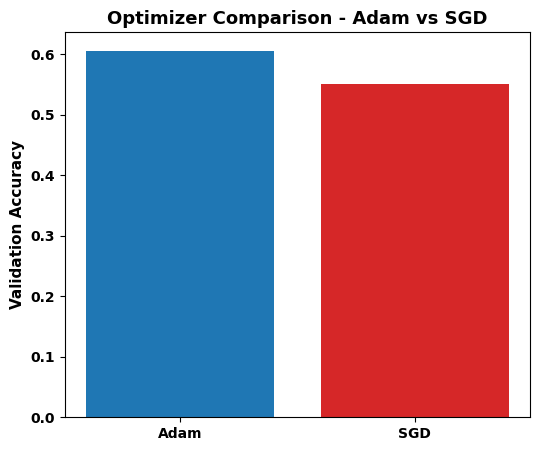

In [10]:
# Exercise 3 — Adam vs SGD
adam_result = next(r for r in hyperparam_results
                    if r['optimizer_name'] == 'adam' and r['batch_size'] == 32
                    and r['learning_rate'] == 0.001 and r['dense_units'] == 128)
sgd_result = next(r for r in hyperparam_results if r['optimizer_name'] == 'sgd')

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(['Adam', 'SGD'], [adam_result['val_accuracy'], sgd_result['val_accuracy']],
       color=['#1f77b4', '#d62728'])
ax.set_title("Optimizer Comparison - Adam vs SGD")
ax.set_ylabel("Validation Accuracy")
save_bold_plot(fig, "optimizer_comparison.png")


Training LeNet-5 from scratch...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3730 - loss: 1.7737 - val_accuracy: 0.4274 - val_loss: 1.6616
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4580 - loss: 1.5352 - val_accuracy: 0.4842 - val_loss: 1.4707
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5036 - loss: 1.4102 - val_accuracy: 0.5126 - val_loss: 1.4054
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5301 - loss: 1.3309 - val_accuracy: 0.5174 - val_loss: 1.3824
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5519 - loss: 1.2666 - val_accuracy: 0.5168 - val_loss: 1.3765
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5701 - loss: 1.2139 - val_accuracy: 0.5236 - val_loss: 1.3563
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5866 - loss: 1.1677 - val_accuracy: 0.5116 - val_loss: 1.3958
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6001 - loss: 1.1271 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.4233 - loss: 1.5867 - val_accuracy: 0.4928 - val_loss: 1.4149
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5668 - loss: 1.2288 - val_accuracy: 0.5866 - val_loss: 1.1931
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.6235 - loss: 1.0869 - val_accuracy: 0.5854 - val_loss: 1.1815
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.6576 - loss: 1.0018 - val_accuracy: 0.6320 - val_loss: 1.0478
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.6827 - loss: 0.9331 - val_accuracy: 0.6188 - val_loss: 1.1132
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7003 - loss: 0.8819 - val_accuracy: 0.6734 - val_loss: 0.9652
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7136 - loss: 0.8535 - val_accuracy: 0.6528 - val_loss: 1.0221
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7318 -

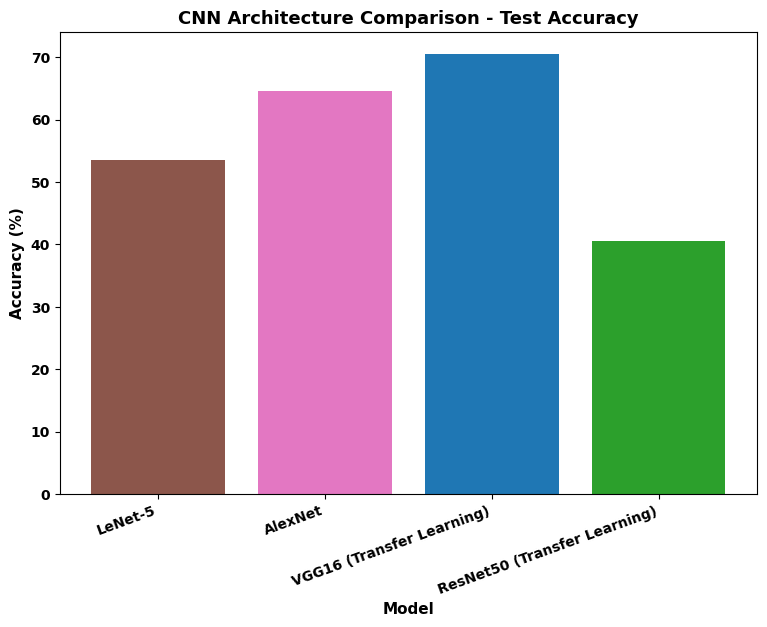

In [11]:
# Exercise 6 — LeNet, AlexNet, ResNet comparison
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Dense

def build_lenet5():
    model = Sequential([
        Conv2D(6, (5, 5), activation='tanh', padding='same', input_shape=INPUT_SHAPE),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(120, activation='tanh'),
        Dense(84, activation='tanh'),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='LeNet5')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def build_alexnet():
    model = Sequential([
        Conv2D(96, (3, 3), strides=1, activation='relu', padding='same', input_shape=INPUT_SHAPE),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='AlexNet')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

EPOCHS_SCRATCH = 10
architecture_results = []

for name, builder in [('LeNet-5', build_lenet5), ('AlexNet', build_alexnet)]:
    print(f"\nTraining {name} from scratch...")
    model_s = builder()
    start = time.time()
    hist_s = model_s.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS_SCRATCH,
        verbose=1
    )
    elapsed = time.time() - start
    pred_s = np.argmax(model_s.predict(x_test), axis=1)
    acc_s = accuracy_score(y_true, pred_s)
    architecture_results.append({
        'Model': name,
        'Parameters': model_s.count_params(),
        'Accuracy (%)': round(acc_s * 100, 2),
        'Training Time (s)': round(elapsed, 2),
    })
    del model_s

architecture_results.append({
    'Model': 'VGG16 (Transfer Learning)',
    'Parameters': vgg_model.count_params(),
    'Accuracy (%)': round(test_accuracy * 100, 2),
    'Training Time (s)': round(vgg_train_time + vgg_finetune_time, 2),
})
architecture_results.append({
    'Model': 'ResNet50 (Transfer Learning)',
    'Parameters': resnet_params,
    'Accuracy (%)': round(resnet_test_acc * 100, 2),
    'Training Time (s)': round(resnet_train_time, 2),
})

arch_df = pd.DataFrame(architecture_results)
arch_df

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#8c564b', '#e377c2', '#1f77b4', '#2ca02c']
ax.bar(arch_df['Model'], arch_df['Accuracy (%)'], color=colors[:len(arch_df)])
ax.set_title("CNN Architecture Comparison - Test Accuracy")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy (%)")
plt.xticks(rotation=20, ha='right', fontweight='bold')
save_bold_plot(fig, "architecture_comparison.png")

In [12]:
# Results Summary
print("=" * 65)
print("FINAL RESULTS - VGG16 Transfer Learning (after fine-tuning)")
print("=" * 65)
print(f"Training Accuracy    : {history_finetune.history['accuracy'][-1]:.4f}")
print(f"Testing Accuracy     : {test_accuracy:.4f}")
print(f"Precision (macro)    : {test_precision:.4f}")
print(f"Recall (macro)       : {test_recall:.4f}")
print(f"F1-score (macro)     : {test_f1:.4f}")
print(f"Total Training Time  : {vgg_train_time + vgg_finetune_time:.2f} sec")
print(f"Total Parameters     : {vgg_model.count_params():,}")

print("\nComparison of CNN Architectures:")
print(arch_df.to_string(index=False))

FINAL RESULTS - VGG16 Transfer Learning (after fine-tuning)
Training Accuracy    : 0.9326
Testing Accuracy     : 0.7048
Precision (macro)    : 0.7028
Recall (macro)       : 0.7048
F1-score (macro)     : 0.7027
Total Training Time  : 362.76 sec
Total Parameters     : 14,781,642

Comparison of CNN Architectures:
                       Model  Parameters  Accuracy (%)  Training Time (s)
                     LeNet-5       83126         53.45              57.50
                     AlexNet     8578314         64.61             260.32
   VGG16 (Transfer Learning)    14781642         70.48             362.76
ResNet50 (Transfer Learning)    23851274         40.52             153.99
